# First Try: Piecing together two copula densities for the bulk and the lower tail


In [3]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import pyvinecopulib as pv
from matplotlib.colors import LogNorm
import math
import torch
import torch.nn.functional as F
from typing import Any, Optional, Callable, cast
from scipy.stats import norm
import pandas as pd
from scipy.special import logsumexp

from npptcop import (
  TailCopula,
  grid_metrics_density,
  unit_grid,
  ProbitTLL,
  ParametricTailCopula,
)

torch.set_default_dtype(torch.float64)

from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.mplot3d.axes3d import Axes3D

from stats import expon_cdf, expon_pdf, expon_ppf, norm_cdf, norm_pdf, norm_ppf


In [4]:
BICOP_PLOT_DOC = """
Generates a plot for a copula density object or callable.
This method generates a contour or surface plot of the copula density.
It can be used to visualize the copula density with different types of margins.

Parameters
----------
plot_type : str (default="contour")
    The type of plot to generate. Either "contour" or "surface".
margin_type : str (default="unif")
    The type of margins to use. Either "unif", "norm", or "exp".
xylim : tuple (default=None)
    The limits for the x and y axes. Automatically set if None.
grid_size : int (default=None)
    The number of grid points to use. Automatically set if None.
cop : Any
    An object with a pdf() method, or a callable pdf function.
density : np.ndarray (default=None)
    Optional precomputed density on the grid. If given, no evaluation is done.

Returns
-------
Nothing, the function generates a plot and shows it using matplotlib.
"""


## Choose the sampled data setting
- `"clayton"`: simple Clayton copula with parameter $\theta = 3$
- `"gumbel"` : simple Gumbel copula with parameter $\theta = 3$ and rotation $180°$
- `"mixture"`: mixture of a Clayton copula ($\theta = 3$) and a rotated Gumbel copula ($90°, \theta = 2$)


In [5]:
setting = "gumbel"

Set the sample size $n$ and the threshold $q$:

In [6]:
n = 10000
q = 0.1  # n ** (-0.5)

### Simulate some data

In [7]:
if setting == "clayton":
  theta = 3.0
  bicop = pv.Bicop(
    family=pv.BicopFamily.clayton,
    parameters=np.array([[theta]], dtype=float),
  )
  u = torch.as_tensor(bicop.simulate(n, seeds=[97]), dtype=torch.float64)

elif setting == "gumbel":
  theta = 3.0
  bicop = pv.Bicop(
    family=pv.BicopFamily.gumbel,
    rotation=180,
    parameters=np.array([[theta]], dtype=float),
  )
  u = torch.as_tensor(bicop.simulate(n, seeds=[97]), dtype=torch.float64)

elif setting == "mixture":
  w = 0.6  # probability of using copula 1

  cop1 = pv.Bicop(
    family=pv.BicopFamily.clayton,
    parameters=np.array([[3.0]], dtype=float),
  )

  cop2 = pv.Bicop(
    family=pv.BicopFamily.gumbel,
    rotation=90,  # upper tail dependence
    parameters=np.array([[2.0]], dtype=float),
  )

  rng = np.random.default_rng(123)
  choose_1 = rng.random(n) < w
  n1 = int(choose_1.sum())
  n2 = n - n1

  u = np.empty((n, 2), dtype=np.float64)
  u[choose_1] = cop1.simulate(n1, seeds=[97])
  u[~choose_1] = cop2.simulate(n2, seeds=[98])

  u = torch.as_tensor(u, dtype=torch.float64)

else:
  raise ValueError(f"Unknown setting: {setting}")


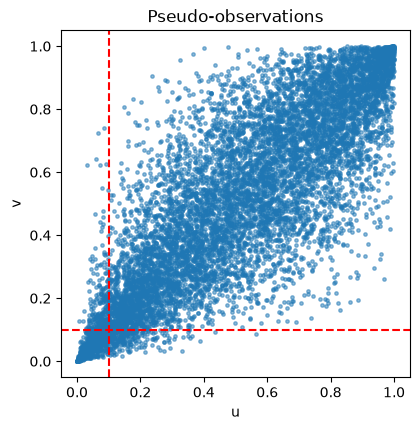

In [8]:
fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.scatter(u[:, 0], u[:, 1], s=6, alpha=0.5)
ax.axvline(q, color="r", ls="--")
ax.axhline(q, color="r", ls="--")
ax.set(xlabel="u", ylabel="v", title="Pseudo-observations")

plt.savefig("../latex/figures/samples_" + setting + ".pdf", bbox_inches="tight")

plt.show()

### Define the grid

In [9]:
grid_size = 100
u_eval, cell_area = unit_grid(grid_size)

# For the lower tail
u_tail_grid = u_eval[u_eval[:, 0] <= q]
u_tail_grid = u_tail_grid[u_tail_grid[:, 1] <= q]

u_tail_grid.shape[0]

100

In [10]:
u_eval_ll = u_eval / q  # only for points in [0, q]^2

### Get the true copula density values:

In [11]:
if setting in {"clayton", "gumbel"}:
  c_true = torch.from_numpy(bicop.pdf(u_eval.numpy()))
elif setting == "mixture":
  c_true = torch.from_numpy(
    w * cop1.pdf(u_eval.numpy()) + (1 - w) * cop2.pdf(u_eval.numpy())
  ).double()

## Approach 1: Fit the lower-left tail estimator (Tail-adaptive TLL)

`TailCopula` extracts the observations in the corner block $[0, q]^2$, rescales them to $[0, 1]^2$, and fits a probit-transform local-likelihood KDE. The fitted summary exposes the tail mass $p = k/n$ and the tail count $k$.


In [12]:
tail_ll = TailCopula(q, rotation=0).fit(u)
fit = tail_ll.fit_
print(f"tail count k = {fit.k}")
print(f"tail mass  p = {fit.p:.4f}")
print(f"bandwidth:\n{fit.bandwidth}")

tail count k = 753
tail mass  p = 0.0753
bandwidth:
tensor([[0.1093, 0.0820],
        [0.0820, 0.1093]])


## Approach 2: Fit a parametric family to the lower-left
Here, we use negative-logistic since it performed best in the simulations study on the lower-left only.

In [13]:
tail_nl_ll = ParametricTailCopula("neg_logistic", q, rotation=0).fit(u)

## Approach 3: Fit the standard TLL to the full grid $[0,1]^2$

In [14]:
tll = ProbitTLL(ridge=1e-6).fit(u)  # learn from the observed sample
c_tll = tll.evaluate(u_eval)  # this is c(u_eval), body block

## Approach 4: Fit a parametric copula to the full grid $[0,1]^2$

In [15]:
mask_ll = (u_eval[:, 0] <= q) & (u_eval[:, 1] <= q)
if setting in {"clayton", "gumbel"}:
  all_except_tll = [
    fam
    for fam in pv.BicopFamily.__members__.values()
    if fam != pv.BicopFamily.tll
  ]

  controls = pv.FitControlsBicop(family_set=all_except_tll)

  bicop_param = pv.Bicop.from_data(data=u.numpy(), controls=controls)
  c_param = torch.from_numpy(bicop_param.pdf(u_eval.numpy()))


elif setting == "mixture":
  # u: (n, 2) numpy array in (0,1)^2
  u = np.asarray(u, dtype=np.float64, order="F")

  # Fixed families / rotations
  cop1_est = pv.Bicop(family=pv.BicopFamily.clayton)
  cop2_est = pv.Bicop(family=pv.BicopFamily.gumbel, rotation=90)

  # Good starting values from separate fits
  cop1_est.fit(
    u,
    controls=pv.FitControlsBicop(
      family_set=[pv.BicopFamily.clayton],
      parametric_method="mle",
    ),
  )
  cop2_est.fit(
    u,
    controls=pv.FitControlsBicop(
      family_set=[pv.BicopFamily.gumbel],
      parametric_method="mle",
      allow_rotations=True,
    ),
  )

  w_est = 0.5

  for _ in range(50):
    # E-step
    log_c1 = np.log(cop1_est.pdf(u))
    log_c2 = np.log(cop2_est.pdf(u))
    log_num1 = np.log(w) + log_c1
    log_num2 = np.log(1.0 - w) + log_c2
    log_denom = logsumexp(np.vstack([log_num1, log_num2]), axis=0)

    r1 = np.exp(log_num1 - log_denom)  # responsibility for component 1
    r2 = 1.0 - r1

    # M-step: weighted refits
    cop1_est.fit(
      u,
      controls=pv.FitControlsBicop(
        family_set=[pv.BicopFamily.clayton],
        parametric_method="mle",
        weights=r1,
      ),
    )
    cop2_est.fit(
      u,
      controls=pv.FitControlsBicop(
        family_set=[pv.BicopFamily.gumbel],
        parametric_method="mle",
        weights=r2,
        allow_rotations=True,
      ),
    )

    w_new = r1.mean()

    if abs(w_new - w) < 1e-8:
      w = w_new
      break
    w_est = w_new

  print("w =", w_est)
  print("cop1 =", cop1_est)
  print("cop2 =", cop2_est)

  c_param = torch.from_numpy(
    w * cop1_est.pdf(u_eval.numpy()) + (1 - w) * cop2_est.pdf(u_eval.numpy())
  ).double()


## PT Approach 1: Hard piecing-together

In [16]:
c_pt_tll_tll = c_tll.clone()
c_pt_tll_tll[mask_ll] = tail_ll.c(u_eval[mask_ll] / q)
# c_pt[mask_ll] = tail_ll.c(u_eval[mask_ll])

In [17]:
c_pt_tll_param = c_tll.clone()
c_pt_tll_param[mask_ll] = tail_ll.c(u_eval[mask_ll] / q)
# c_pt_tll_param[mask_ll] = tail_ll.c(u_eval[mask_ll])

In [18]:
c_pt_param_param = c_param.clone()
c_pt_param_param[mask_ll] = tail_nl_ll.c(u_eval[mask_ll] / q)

## PT Approach 2: Smooth transition between the two copulas

In [19]:
def lower_left_linear_alpha(u_eval, q=0.1, eps=0.02):
  """
  Linear transition only inside [0,q]^2.

  alpha = 1            for max(u,v) <= q - eps
  alpha = linear decay for q - eps < max(u,v) < q
  alpha = 0            for max(u,v) >= q
  """
  u = u_eval[:, 0]
  v = u_eval[:, 1]

  r = torch.maximum(u, v)
  alpha = torch.zeros_like(r)

  inner = r <= (q - eps)
  band = (r > (q - eps)) & (r < q)

  alpha[inner] = 1.0
  alpha[band] = (q - r[band]) / eps

  return alpha

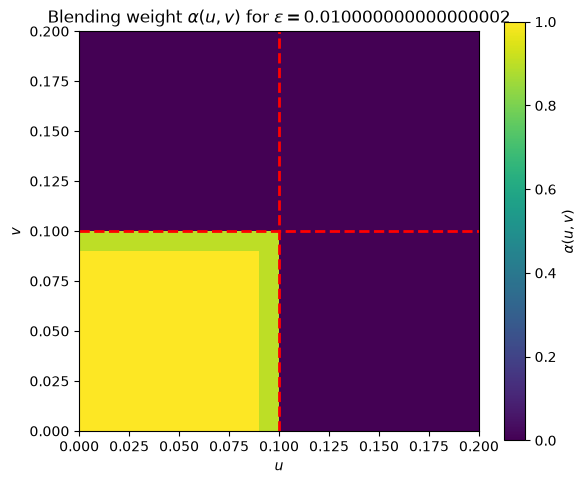

In [ ]:
eps = q ** (2)  # 0.01
alpha = lower_left_linear_alpha(u_eval, q=q, eps=eps)
alpha_grid = alpha.reshape(grid_size, grid_size)

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(
  alpha_grid.T.detach().numpy(),  # transpose for correct orientation
  origin="lower",
  interpolation="nearest",
  extent=[0.0, 1.0, 0.0, 1.0],
  aspect="equal",
)

# Zoom into the lower-left half
ax.set_xlim(0.0, 0.2)
ax.set_ylim(0.0, 0.2)

# Highlight the PT boundary
ax.axvline(q, color="red", linestyle="--", linewidth=2)
ax.axhline(q, color="red", linestyle="--", linewidth=2)

ax.set_xlabel(r"$u$")
ax.set_ylabel(r"$v$")
ax.set_title("Blending weight $\\alpha(u,v)$ for $\\varepsilon={}$".format(eps))

fig.colorbar(im, ax=ax, label=r"$\alpha(u,v)$")

fig.tight_layout()
fig.savefig(
  "../latex/figures/alpha_blending_ll.pdf",
  bbox_inches="tight",
)

plt.show()

In [21]:
mask_alpha = alpha > 0

In [ ]:
c_pt_tll_tll_smooth = (1.0 - alpha) * c_tll + alpha * tail_ll.c(u_eval / q)

In [24]:
c_pt_tll_param_smooth = (1.0 - alpha) * c_tll + alpha * tail_nl_ll.c(u_eval / q)

In [ ]:
c_pt_param_param_smooth = (1.0 - alpha) * c_param + alpha * tail_nl_ll.c(
  u_eval / q
)

## Evaluation

Plot the contours.

In [ ]:
def get_default_xylim(margin_type: str) -> tuple[float, float]:
  if margin_type == "unif":
    return (1e-2, 1 - 1e-2)
  elif margin_type == "norm":
    return (-3, 3)
  elif margin_type == "exp":
    return (0, 6)
  else:
    raise ValueError("Unknown margin type")


def get_default_grid_size(plot_type: str) -> int:
  if plot_type == "contour":
    return 100
  elif plot_type == "surface":
    return 40
  else:
    raise ValueError("Unknown plot type")


def copula_density_plot(
  estimator: str = "tll",
  plot_type: str = "surface",
  margin_type: str = "norm",
  q: float = 0.1,
  xylim: Optional[tuple[float, float]] = None,
  grid_size: Optional[int] = None,
  ax: Optional[Any] = None,
) -> None:
  """{}""".format(BICOP_PLOT_DOC)

  if plot_type not in ["contour", "surface"]:
    raise ValueError("Unknown type")

  if margin_type not in ["unif", "norm", "exp"]:
    raise ValueError("Unknown margin type")

  if xylim is None:
    xylim = get_default_xylim(margin_type)
  if grid_size is None:
    grid_size = get_default_grid_size(plot_type)

  if margin_type == "unif":
    if plot_type == "contour":
      points = np.linspace(1e-5, 1 - 1e-5, grid_size)
    else:
      points = np.linspace(1, grid_size, grid_size) / (grid_size + 1)

    g = np.meshgrid(points, points)
    points = g[0][0]
    adj = 1
    levels = [0.2, 0.6, 1, 1.5, 2, 3, 5, 10, 20]
    xlabel = "u1"
    ylabel = "u2"

  elif margin_type == "norm":
    points = norm_cdf(np.linspace(xylim[0], xylim[1], grid_size))
    g = np.meshgrid(points, points)
    points = norm_ppf(g[0][0])
    adj = np.outer(norm_pdf(points), norm_pdf(points))
    levels = [0.01, 0.025, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5]
    xlabel = "z1"
    ylabel = "z2"

  elif margin_type == "exp":
    ll = 1e-2 if plot_type == "contour" else 1e-1
    points = expon_cdf(np.linspace(ll, xylim[1], grid_size))
    g = np.meshgrid(points, points)
    points = expon_ppf(g[0][0])
    adj = np.outer(expon_pdf(points), expon_pdf(points))
    levels = [0.005, 0.01, 0.025, 0.05, 0.1, 0.2, 0.3, 0.5]
    xlabel = "e1"
    ylabel = "e2"

  else:
    raise ValueError("Unknown margin type")

  # evaluate on grid
  if estimator == "true":
    if setting in {"clayton", "gumbel"}:
      vals = torch.from_numpy(bicop.pdf(np.stack(g, axis=-1).reshape(-1, 2)))

    elif setting == "mixture":
      vals = torch.from_numpy(
        w * cop1.pdf(np.stack(g, axis=-1).reshape(-1, 2))
        + (1 - w) * cop2.pdf(np.stack(g, axis=-1).reshape(-1, 2))
      ).double()

  elif estimator == "tll":
    vals = tll.evaluate(torch.from_numpy(np.stack(g, axis=-1).reshape(-1, 2)))

  elif estimator == "pt_tll_param":
    vals_body = tll.evaluate(
      torch.from_numpy(np.stack(g, axis=-1).reshape(-1, 2))
    )

    vals_tail = tail_nl_ll.c(
      torch.from_numpy(np.stack(g, axis=-1).reshape(-1, 2)) / q
    )
    mask_ll = (g[0].flatten() <= q) & (g[1].flatten() <= q)

    vals = vals_body.clone()
    vals[mask_ll] = vals_tail[mask_ll]
  elif estimator == "pt_tll_tll":
    vals_body = tll.evaluate(
      torch.from_numpy(np.stack(g, axis=-1).reshape(-1, 2))
    )

    vals_tail = tail_ll.c(
      torch.from_numpy(np.stack(g, axis=-1).reshape(-1, 2)) / q
    )
    mask_ll = (g[0].flatten() <= q) & (g[1].flatten() <= q)

    vals = vals_body.clone()
    vals[mask_ll] = vals_tail[mask_ll]

  elif estimator == "pt_param_param":
    if setting in {"clayton", "gumbel"}:
      all_except_tll = [
        fam
        for fam in pv.BicopFamily.__members__.values()
        if fam != pv.BicopFamily.tll
      ]

      controls = pv.FitControlsBicop(family_set=all_except_tll)

      bicop_param = pv.Bicop.from_data(data=u, controls=controls)

      vals_body = torch.from_numpy(
        bicop_param.pdf(np.stack(g, axis=-1).reshape(-1, 2))
      )

    elif setting == "mixture":
      vals_body = torch.from_numpy(
        w_est * cop1_est.pdf(np.stack(g, axis=-1).reshape(-1, 2))
        + (1 - w_est) * cop2_est.pdf(np.stack(g, axis=-1).reshape(-1, 2))
      ).double()

    vals_tail = tail_ll.c(
      torch.from_numpy(np.stack(g, axis=-1).reshape(-1, 2)) / q
    )
    mask_ll = (g[0].flatten() <= q) & (g[1].flatten() <= q)

    vals = vals_body.clone()
    vals[mask_ll] = vals_tail[mask_ll]

  elif estimator == "parametric":
    if setting in {"clayton", "gumbel"}:
      all_except_tll = [
        fam
        for fam in pv.BicopFamily.__members__.values()
        if fam != pv.BicopFamily.tll
      ]

      controls = pv.FitControlsBicop(family_set=all_except_tll)

      bicop_param = pv.Bicop.from_data(data=u, controls=controls)
      vals = torch.from_numpy(
        bicop_param.pdf(np.stack(g, axis=-1).reshape(-1, 2))
      )
    elif setting == "mixture":
      vals = torch.from_numpy(
        w_est * cop1_est.pdf(np.stack(g, axis=-1).reshape(-1, 2))
        + (1 - w_est) * cop2_est.pdf(np.stack(g, axis=-1).reshape(-1, 2))
      ).double()

  elif estimator == "pt_tll_tll_smooth":
    vals = (1.0 - alpha) * tll.evaluate(
      torch.from_numpy(np.stack(g, axis=-1).reshape(-1, 2))
    ) + alpha * tail_ll.c(
      torch.from_numpy(np.stack(g, axis=-1).reshape(-1, 2)) / q
    )

  elif estimator == "pt_tll_param_smooth":
    vals = (1.0 - alpha) * tll.evaluate(
      torch.from_numpy(np.stack(g, axis=-1).reshape(-1, 2))
    ) + alpha * tail_nl_ll.c(
      torch.from_numpy(np.stack(g, axis=-1).reshape(-1, 2)) / q
    )

  elif estimator == "pt_param_param_smooth":
    if setting in {"clayton", "gumbel"}:
      all_except_tll = [
        fam
        for fam in pv.BicopFamily.__members__.values()
        if fam != pv.BicopFamily.tll
      ]

      controls = pv.FitControlsBicop(family_set=all_except_tll)

      bicop_param = pv.Bicop.from_data(data=u, controls=controls)

      vals = (1.0 - alpha) * torch.from_numpy(
        bicop_param.pdf(np.stack(g, axis=-1).reshape(-1, 2))
      ) + alpha * tail_nl_ll.c(
        torch.from_numpy(np.stack(g, axis=-1).reshape(-1, 2)) / q
      )

    elif setting == "mixture":
      vals_body = torch.from_numpy(
        w_est * cop1_est.pdf(np.stack(g, axis=-1).reshape(-1, 2))
        + (1 - w_est) * cop2_est.pdf(np.stack(g, axis=-1).reshape(-1, 2))
      ).double()

      vals = (1.0 - alpha) * vals_body + alpha * tail_nl_ll.c(
        torch.from_numpy(np.stack(g, axis=-1).reshape(-1, 2)) / q
      )

  else:
    raise ValueError("Unknown estimator type")

  cop = np.reshape(vals, (grid_size, grid_size))
  dens = cop * adj

  if len(np.unique(dens)) == 1:
    dens[0] = 1.000001 * dens[0]

  if margin_type == "unif":
    zlim = (0, max(3, 1.1 * max(dens.flatten())))
  elif margin_type == "norm":
    zlim = (0, max(0.4, 1.1 * max(dens.flatten())))
  elif margin_type == "exp":
    dens = np.minimum(dens, 6)
    zlim = (0, max(1, 1.1 * max(dens.flatten())))
  else:
    raise ValueError("Unknown margin type")

  colors = [
    "#00007F",
    "blue",
    "#007FFF",
    "cyan",
    "#7FFF7F",
    "yellow",
    "#FF7F00",
    "red",
    "#7F0000",
  ]

  jet_colors = LinearSegmentedColormap.from_list("jet_colors", colors, N=100)

  if plot_type == "contour":
    if ax is None:
      ax = plt.gca()

    contour = ax.contour(points, points, dens, levels=levels, cmap="gray")
    ax.clabel(contour, inline=True, fontsize=8, fmt="%1.2f")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

  elif plot_type == "surface":
    fig = plt.figure()
    ax = cast(Axes3D, fig.add_subplot(111, projection="3d"))
    ax.view_init(elev=30, azim=-110)

    X, Y = np.meshgrid(points, points)
    ax.plot_surface(X, Y, dens, cmap=jet_colors, edgecolor="none", shade=False)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xlim(xylim)
    ax.set_ylim(xylim)
    ax.set_zlim(zlim)
    ax.set_box_aspect([1, 1, 1])
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.grid(False)
    plt.draw()
    plt.show()

  else:
    raise ValueError("Unknown plot type")

/tmp/ipykernel_882781/2872375144.py:213: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  dens = cop * adj


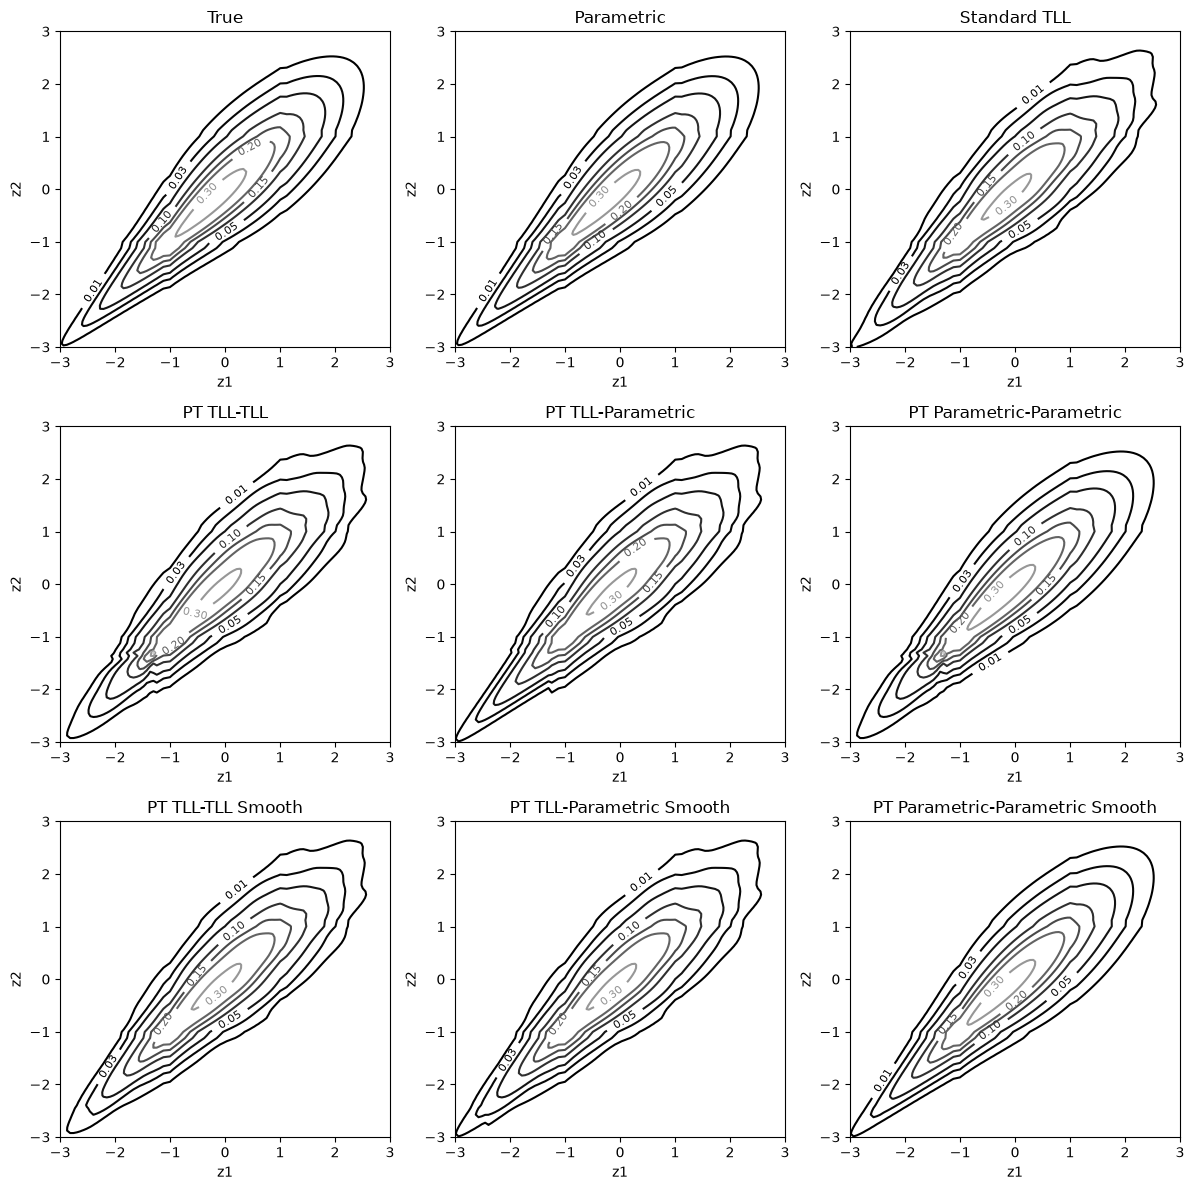

In [34]:
# fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

estimators = [
  "true",
  "parametric",
  "tll",
  "pt_tll_tll",
  "pt_tll_param",
  "pt_param_param",
  "pt_tll_tll_smooth",
  "pt_tll_param_smooth",
  "pt_param_param_smooth",
]
titles = [
  "True",
  "Parametric",
  "Standard TLL",
  "PT TLL-TLL",
  "PT TLL-Parametric",
  "PT Parametric-Parametric",
  "PT TLL-TLL Smooth",
  "PT TLL-Parametric Smooth",
  "PT Parametric-Parametric Smooth",
]

for ax, est in zip(axes.ravel(), estimators):
  copula_density_plot(
    estimator=est,
    plot_type="contour",
    ax=ax,
  )
  ax.set_title(titles[estimators.index(est)])

plt.tight_layout()

# plt.savefig(
#   "../latex/figures/contours_pt_" + setting + "_smooth_" + ".pdf",
#   bbox_inches="tight",
# )

plt.show()


## Compute evaluation metrics: ISE, IAE and KL

In [35]:
estimators = {
  "Parametric": c_param,
  "TLL": c_tll,
  "PT TLL-TLL": c_pt_tll_tll,
  "PT-TLL-Param": c_pt_tll_param,
  "PT-Param-Param": c_pt_param_param,
  "PT-TLL-TLL Smooth": c_pt_tll_tll_smooth,
  "PT-TLL-Param Smooth": c_pt_tll_param_smooth,
  "PT-Param-Param Smooth": c_pt_param_param_smooth,
}

results = {}

for name, c in estimators.items():
  results[name] = grid_metrics_density(c, c_true, cell_area)

df = pd.DataFrame(results).T  # estimators as rows
print(df.round(5))

                             ISE      IAE       KL
Parametric               0.52995  0.01633  0.00011
TLL                    143.54507  0.22823  0.13565
PT TLL-TLL              21.32817  0.13997  0.12783
PT-TLL-Param            21.32817  0.13997  0.12783
PT-Param-Param          11.31615  0.04418  0.00103
PT-TLL-TLL Smooth       21.32697  0.13977  0.12775
PT-TLL-Param Smooth     28.64106  0.14493  0.12709
PT-Param-Param Smooth   11.31615  0.04417  0.00102


### Evaluate on the lower tail only

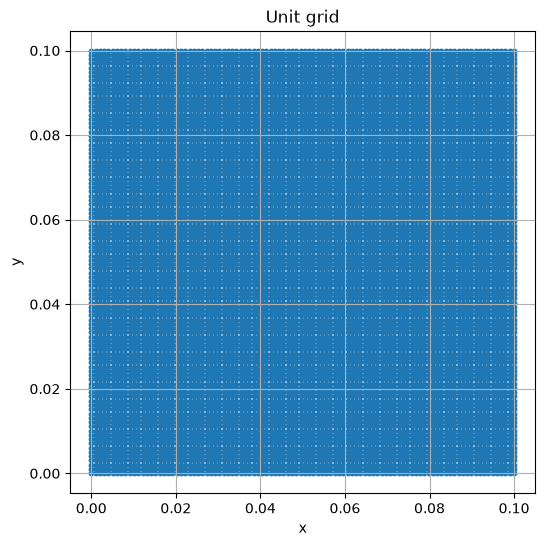

In [36]:
grid_eval_ll = u_eval * q


plt.figure(figsize=(6, 6))
plt.scatter(grid_eval_ll[:, 0], grid_eval_ll[:, 1], s=10)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Unit grid")
plt.axis("equal")
plt.grid(True)
# plt.xlim(0, 1)
# plt.ylim(0, 1)
plt.show()

In [37]:
# body block
c_tll_body_ll = tll.evaluate(grid_eval_ll)

if setting in {"clayton", "gumbel"}:
  c_param_body_ll = torch.from_numpy(bicop_param.pdf(grid_eval_ll.numpy()))
elif setting == "mixture":
  c_param_body_ll = torch.from_numpy(
    w * cop1_est.pdf(grid_eval_ll.numpy())
    + (1 - w) * cop2_est.pdf(grid_eval_ll.numpy())
  ).double()

# tail block
c_tll_tail_ll = tail_ll.c(grid_eval_ll / q)
c_param_tail_ll = tail_nl_ll.c(grid_eval_ll / q)

# True density
if setting in {"clayton", "gumbel"}:
  c_true_ll = torch.from_numpy(bicop.pdf(grid_eval_ll.numpy()))
elif setting == "mixture":
  c_true_ll = torch.from_numpy(
    w * cop1.pdf(grid_eval_ll.numpy())
    + (1 - w) * cop2.pdf(grid_eval_ll.numpy())
  ).double()

In [38]:
estimators = {
  "Parametric-Body": c_param_body_ll,
  "TLL-Body": c_tll_body_ll,
  "Parametric-Tail": c_param_tail_ll,
  "TLL-Tail": c_tll_tail_ll,
}
results = {}

for name, c in estimators.items():
  results[name] = grid_metrics_density(c, c_true_ll, cell_area * q**2)

df = pd.DataFrame(results).T  # estimators as rows
print(df.round(7))

                         ISE       IAE        KL
Parametric-Body     0.520933  0.001377  0.000008
TLL-Body         2928.158227  0.061822  0.068396
Parametric-Tail    11.342923  0.005688  0.000244
TLL-Tail         1547.719384  0.053726  0.030225


### Evaluate the transition region

In [ ]:
# Find all values with alpha between 0 and 1
alpha_mask = (alpha > 0) & (alpha < 1)

estimators = {
  "Parametric": c_param,
  "TLL": c_tll,
  "PT TLL-TLL": c_pt_tll_tll,
  "PT-TLL-Param": c_pt_tll_param,
  "PT-Param-Param": c_pt_param_param,
  "PT-TLL-TLL Smooth": c_pt_tll_tll_smooth,
  "PT-TLL-Param Smooth": c_pt_tll_param_smooth,
  "PT-Param-Param Smooth": c_pt_param_param_smooth,
}

results = {}

for name, c in estimators.items():
  results[name] = grid_metrics_density(
    c[alpha_mask], c_true[alpha_mask], cell_area
  )

df = pd.DataFrame(results).T  # estimators as rows
print(df.round(6))

                            ISE       IAE        KL
Parametric             0.000004  0.000065  0.000000
TLL                    0.000234  0.000536  0.000044
PT TLL-TLL             0.006351  0.002184  0.000428
PT-TLL-Param           0.006351  0.002184  0.000428
PT-Param-Param         0.000029  0.000187  0.000012
PT-TLL-TLL Smooth      0.005159  0.001981  0.000354
PT-TLL-Param Smooth    0.000023  0.000167  0.000008
PT-Param-Param Smooth  0.000024  0.000170  0.000010
